# Multi-station passenger-flow pipeline

In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from metroflow.multistation.stage1 import (
    MultiStationStage1Config,
    DEFAULT_CLASSIC_METRO_LINE_CODES,
    build_station_place_maps,
    build_multistation_bucket_parquet,
    make_multistation_supervised_frame,
    make_multistation_weekday_split,
    run_multistation_stage1,
    save_multistation_stage1_result,
)


## Конфигурация

In [2]:
FORCE_REBUILD_PARQUET = False
USE_WEATHER = False
N_BOOTSTRAP = 500
cfg = MultiStationStage1Config(
    name='multistation_pipeline_classic_metro',
    data_dir=str(PROJECT_ROOT / 'data'),
    pass_filename='PASS_ALL_202503242210.csv',
    cache_dir=str(PROJECT_ROOT / 'data' / 'cache'),
    output_dir=str(PROJECT_ROOT / 'outputs' / 'multistation_pipeline_classic_metro'),
    bucket_minutes=15,
    horizon_minutes=60,
    operational_day_start_hour=3,
    classic_metro_only=True,
    classic_metro_line_codes=DEFAULT_CLASSIC_METRO_LINE_CODES,
    line_filter=None,
    use_weather_features=USE_WEATHER,
    weather_csv=str(PROJECT_ROOT / 'data' / 'weather_moscow_hourly_openmeteo_20250310_20250316.csv'),
    n_bootstrap=N_BOOTSTRAP,
    run_local_ets=True,
    run_global_lstm=True,
    run_global_transformer=True,
    lstm_max_epochs=35,
    transformer_max_epochs=25,
    seq_patience=5,
)
cfg


MultiStationStage1Config(name='multistation_pipeline_classic_metro', data_dir='/home/ubuntu/DIPLOM/metro_forecasting_research/data', pass_filename='PASS_ALL_202503242210.csv', pass_sep=';', ref_places_glob='REF_PSG_PLACES*.csv', cache_dir='/home/ubuntu/DIPLOM/metro_forecasting_research/data/cache', output_dir='/home/ubuntu/DIPLOM/metro_forecasting_research/outputs/multistation_pipeline_classic_metro', bucket_minutes=15, horizon_minutes=60, operational_day_start_hour=3, transport_type_id=1, place_type_id=1, classic_metro_only=True, classic_metro_line_codes=(8, 9, 12, 13, 14, 15, 16, 17, 18, 609, 1500, 1509, 1691, 1749, 1779, 2162), line_filter=None, use_weather_features=False, weather_csv='/home/ubuntu/DIPLOM/metro_forecasting_research/data/weather_moscow_hourly_openmeteo_20250310_20250316.csv', station_places_csv=None, station_buckets_parquet=None, weekday_filter=[0, 1, 2, 3], highload_quantile=0.8, load_weight_gamma=1.0, top_k_boost_models=3, random_state=3228, n_bootstrap=500, run_re

## Справочник станций

In [3]:
stations, places = build_station_place_maps(cfg, save=True)
display(pd.DataFrame({
    'stations': [stations['station_key'].nunique()],
    'places': [places['PLACE_ID'].nunique()],
    'lines': [stations['LN_CODE'].nunique()],
}))
display(stations.head(10))


,stations,places,lines
0,267,490,16


,station_key,ST_CODE,ST_NAME,ST_NAME_SHORT,LN_CODE,LN_NAME,LN_NAME_SHORT,n_place_ids,place_ids,station_order_on_line_proxy,line_n_stations,station_order_norm,is_ring_line_proxy,distance_to_nearest_terminal_proxy,distance_to_nearest_terminal_norm,is_terminal_proxy
0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2,"1597,38915",1,27,0.000000,0,0.0,0.000000,1
1,ln00008_st00022,22,Черкизовская,Черкизовская,8,Сокольническая линия,Сокольническая,2,"1630,1631",2,27,0.038462,0,1.0,0.038462,0
2,ln00008_st00025,25,Преображенская пл.,Преображенск. пл,8,Сокольническая линия,Сокольническая,2,"1616,1617",3,27,0.076923,0,2.0,0.076923,0
3,ln00008_st00028,28,Сокольники,Сокольники СЛ,8,Сокольническая линия,Сокольническая,1,1622,4,27,0.115385,0,3.0,0.115385,0
4,ln00008_st00030,30,Красносельская,Красносельская,8,Сокольническая линия,Сокольническая,1,1603,5,27,0.153846,0,4.0,0.153846,0
5,ln00008_st00032,32,Комсомольская (СОКОЛЬНИЧЕСКАЯ),Комсомольск. СЛ,8,Сокольническая линия,Сокольническая,1,1602,6,27,0.192308,0,5.0,0.192308,0
6,ln00008_st00034,34,Красные ворота,Красные ворота,8,Сокольническая линия,Сокольническая,3,"1604,1606,38937",7,27,0.230769,0,6.0,0.230769,0
7,ln00008_st00037,37,Чистые пруды,Чистые пруды,8,Сокольническая линия,Сокольническая,1,1632,8,27,0.269231,0,7.0,0.269231,0
8,ln00008_st00039,39,Лубянка,Лубянка,8,Сокольническая линия,Сокольническая,2,"1609,1610",9,27,0.307692,0,8.0,0.307692,0
9,ln00008_st00042,42,Охотный ряд,Охотный ряд,8,Сокольническая линия,Сокольническая,2,"39018,39019",10,27,0.346154,0,9.0,0.346154,0


## Parquet 15m

In [4]:
bucket_path = build_multistation_bucket_parquet(cfg, places, force=FORCE_REBUILD_PARQUET)
buckets = pd.read_parquet(bucket_path)
display(pd.DataFrame({
    'parquet': [str(bucket_path)],
    'rows': [len(buckets)],
    'stations': [buckets['station_key'].nunique()],
    'from': [buckets[cfg.time_col].min()],
    'to': [buckets[cfg.time_col].max()],
}))
display(buckets.head(10))


,parquet,rows,stations,from,to
0,/home/ubuntu/DIPLOM/metro_forecasting_research...,154704,260,2025-03-10,2025-03-16 23:45:00


,station_key,ST_CODE,ST_NAME,ST_NAME_SHORT,LN_CODE,LN_NAME,LN_NAME_SHORT,bucket_15m,count
0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 00:00:00,27.0
1,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 00:15:00,19.0
2,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 00:30:00,14.0
3,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 00:45:00,16.0
4,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 01:00:00,4.0
5,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 01:15:00,1.0
6,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 01:30:00,2.0
7,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 01:45:00,1.0
8,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 02:15:00,1.0
9,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2025-03-10 02:45:00,1.0


## Фичи и временной split

In [5]:
frame = make_multistation_supervised_frame(buckets, cfg)
split = make_multistation_weekday_split(frame, cfg)
rows = []
for name in ['train_tune', 'val_df', 'train_full', 'test_df']:
    df = split[name]
    rows.append({
        'split': name,
        'rows': len(df),
        'stations': df['station_key'].nunique(),
        'from': df[cfg.time_col].min(),
        'to': df[cfg.time_col].max(),
    })
display(pd.DataFrame(rows))
display(frame.head(10))


,split,rows,stations,from,to
0,train_tune,47840,260,2025-03-10 03:00:00,2025-03-12 01:45:00
1,val_df,23920,260,2025-03-12 03:00:00,2025-03-13 01:45:00
2,train_full,71760,260,2025-03-10 03:00:00,2025-03-13 01:45:00
3,test_df,23920,260,2025-03-13 03:00:00,2025-03-14 01:45:00


,bucket_15m,count,station_key,ST_CODE,ST_NAME,ST_NAME_SHORT,LN_CODE,LN_NAME,LN_NAME_SHORT,target_h,...,local_slope_2,daylag_deviation,prev_count_ratio_daylag,station_key_code,station_name_code,line_name_code,station_id_raw,line_id_raw,station_code,line_code
0,2025-03-10 00:00:00,27.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,53.0,...,NaN,NaN,NaN,0,16,11,19,8,0,8
1,2025-03-10 00:15:00,19.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,35.0,...,NaN,NaN,NaN,0,16,11,19,8,0,8
2,2025-03-10 00:30:00,14.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,23.0,...,NaN,NaN,NaN,0,16,11,19,8,0,8
3,2025-03-10 00:45:00,16.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,8.0,...,-13.0,NaN,NaN,0,16,11,19,8,0,8
4,2025-03-10 01:00:00,4.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,4.0,...,-3.0,NaN,NaN,0,16,11,19,8,0,8
5,2025-03-10 01:15:00,1.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,4.0,...,-10.0,NaN,NaN,0,16,11,19,8,0,8
6,2025-03-10 01:30:00,2.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2.0,...,-15.0,NaN,NaN,0,16,11,19,8,0,8
7,2025-03-10 01:45:00,1.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2.0,...,-2.0,NaN,NaN,0,16,11,19,8,0,8
8,2025-03-10 02:00:00,0.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,2.0,...,0.0,NaN,NaN,0,16,11,19,8,0,8
9,2025-03-10 02:15:00,1.0,ln00008_st00019,19,Бульвар Рокоссовского,Б.Рокоссовского,8,Сокольническая линия,Сокольническая,1.0,...,-2.0,NaN,NaN,0,16,11,19,8,0,8


## Обучение, ансамбли, bootstrap

In [6]:
result = run_multistation_stage1(cfg, force_rebuild_buckets=False)
saved = save_multistation_stage1_result(result)
display(pd.DataFrame(saved.items(), columns=['artifact', 'path']))


,artifact,path
0,micro_metrics,/home/ubuntu/DIPLOM/metro_forecasting_research...
1,macro_metrics,/home/ubuntu/DIPLOM/metro_forecasting_research...
2,station_bootstrap_metric_ci,/home/ubuntu/DIPLOM/metro_forecasting_research...
3,station_bootstrap_delta_ci,/home/ubuntu/DIPLOM/metro_forecasting_research...
4,test_predictions,/home/ubuntu/DIPLOM/metro_forecasting_research...
5,validation_predictions,/home/ubuntu/DIPLOM/metro_forecasting_research...
6,stations_used,/home/ubuntu/DIPLOM/metro_forecasting_research...


## Признаки

In [7]:
display(pd.DataFrame({'base_features': pd.Series(result['base_features'])}))
display(pd.DataFrame({'rich_features': pd.Series(result['rich_features'])}))


,base_features
0,station_key_code
1,station_id_raw
2,line_id_raw
3,station_name_code
4,line_name_code
5,n_place_ids
6,line_n_stations
7,station_order_on_line_proxy
8,station_order_norm
9,distance_to_nearest_terminal_proxy


,rich_features
0,station_key_code
1,station_id_raw
2,line_id_raw
3,station_name_code
4,line_name_code
5,n_place_ids
6,line_n_stations
7,station_order_on_line_proxy
8,station_order_norm
9,distance_to_nearest_terminal_proxy


## Метрики

In [8]:
display(Markdown('### Micro'))
display(result['micro_table'])
display(Markdown('### Macro'))
display(result['macro_table'])


### Micro

,MAE,RMSE,wMAPE,LW-MAE,HL-MAE,HL-underMAE,HL-underRate
Residual Linear,57.236629,134.781800,0.045220,81.983901,95.967904,46.368964,0.487133
ETS local,57.480356,110.112948,0.045413,82.522304,98.303955,48.007930,0.441851
Residual XGB LW,54.935767,137.802703,0.043402,83.038479,98.007396,47.785925,0.477359
Meta static,55.406989,127.763309,0.043774,83.271953,97.830436,45.301760,0.450229
Meta context,55.637890,129.960038,0.043957,83.777679,98.849503,45.592748,0.452424
Residual XGB,55.586845,138.558808,0.043917,83.930587,98.663088,49.601286,0.493916
Meta static LW,55.906804,130.444044,0.044169,84.227255,98.918697,45.675522,0.452623
Meta context LW,55.966469,132.774571,0.044217,84.322953,100.290078,45.996750,0.453022
Residual Linear LW,62.629989,138.473963,0.049481,85.030260,99.694141,43.931384,0.463196
Seasonal daylag,58.704599,141.970009,0.046380,88.818168,104.141632,47.632954,0.456613


### Macro

,MAE,RMSE,wMAPE,LW-MAE,HL-MAE,HL-underMAE,HL-underRate
Residual Linear,57.236629,87.859856,0.068116,81.983901,93.617101,43.770286,0.480378
ETS local,57.480356,83.133869,0.053000,82.522304,94.786421,43.509576,0.432177
Residual XGB LW,54.935767,88.569555,0.055306,83.038479,95.409765,44.943435,0.470232
Meta static,55.406989,87.691474,0.051806,83.271953,95.223304,42.203198,0.442891
Meta context,55.637890,88.188166,0.051949,83.777679,96.261370,42.565566,0.445213
Residual XGB,55.586845,89.743401,0.054737,83.930587,95.973216,46.663613,0.486541
Meta static LW,55.906804,88.880392,0.052289,84.227255,96.338224,42.655458,0.445427
Meta context LW,55.966469,88.594151,0.052091,84.322953,97.715964,43.053656,0.446140
Residual Linear LW,62.629989,92.483329,0.089562,85.030260,97.574804,41.523056,0.456593
Seasonal daylag,58.704599,94.337037,0.054923,88.818168,101.624621,44.894801,0.450382


## Доверительные интервалы

In [9]:
delta_ci = result['bootstrap']['delta_ci']
key_ci = delta_ci[
    (delta_ci['mode'] == 'micro')
    & (delta_ci['baseline'].isin(['ETS local', 'Seasonal daylag']))
    & (delta_ci['metric'].isin(['LW-MAE', 'HL-MAE', 'HL-underMAE']))
].sort_values(['baseline', 'metric', 'delta_estimate'], ascending=[True, True, False])
display(key_ci)


,mode,model,baseline,metric,delta_estimate,ci_low,ci_high,significant_95
186,micro,Residual Linear,ETS local,HL-MAE,2.336051,-2.600295,7.807674,False
158,micro,Meta static,ETS local,HL-MAE,0.473520,-3.802566,5.669108,False
207,micro,Residual XGB LW,ETS local,HL-MAE,0.296559,-4.383838,5.659295,False
193,micro,Residual XGB,ETS local,HL-MAE,-0.359133,-5.080981,5.101285,False
165,micro,Meta context,ETS local,HL-MAE,-0.545548,-4.918546,4.768292,False
...,...,...,...,...,...,...,...,...
17,micro,MegaBoost rich,Seasonal daylag,LW-MAE,-70.760289,-86.749148,-59.521339,True
24,micro,MegaBoost base norm,Seasonal daylag,LW-MAE,-153.071821,-168.664651,-138.715786,True
38,micro,Global LSTM,Seasonal daylag,LW-MAE,-158.582148,-171.018527,-145.583850,True
45,micro,Global Transformer-lite,Seasonal daylag,LW-MAE,-165.630086,-179.473980,-150.994100,True


## Meta pool и веса

In [10]:
display(result['meta']['validation_selection_table'])
display(pd.Series(result['meta']['static_weights'], name='Meta static').to_frame())
display(pd.Series(result['meta']['static_lw_weights'], name='Meta static LW').to_frame())


,model,val_MAE,val_LW-MAE,val_HL-MAE
0,Seasonal daylag,57.482651,95.993724,115.852993
1,ETS local,69.269502,100.507434,118.184226
2,MegaBoost rich norm,72.283744,126.327249,150.418459
3,MegaBoost rich,103.716083,189.083184,235.672437
4,MegaBoost base norm,132.101520,258.583533,325.852189
5,Global Transformer-lite,162.783299,270.067296,335.252463
6,Global LSTM,163.354733,284.175067,359.497428
7,MegaBoost base,151.716776,297.543613,368.581243


,Meta static
Seasonal daylag,0.749711
ETS local,0.250289


,Meta static LW
Seasonal daylag,0.801435
ETS local,0.198565


## Графики линии

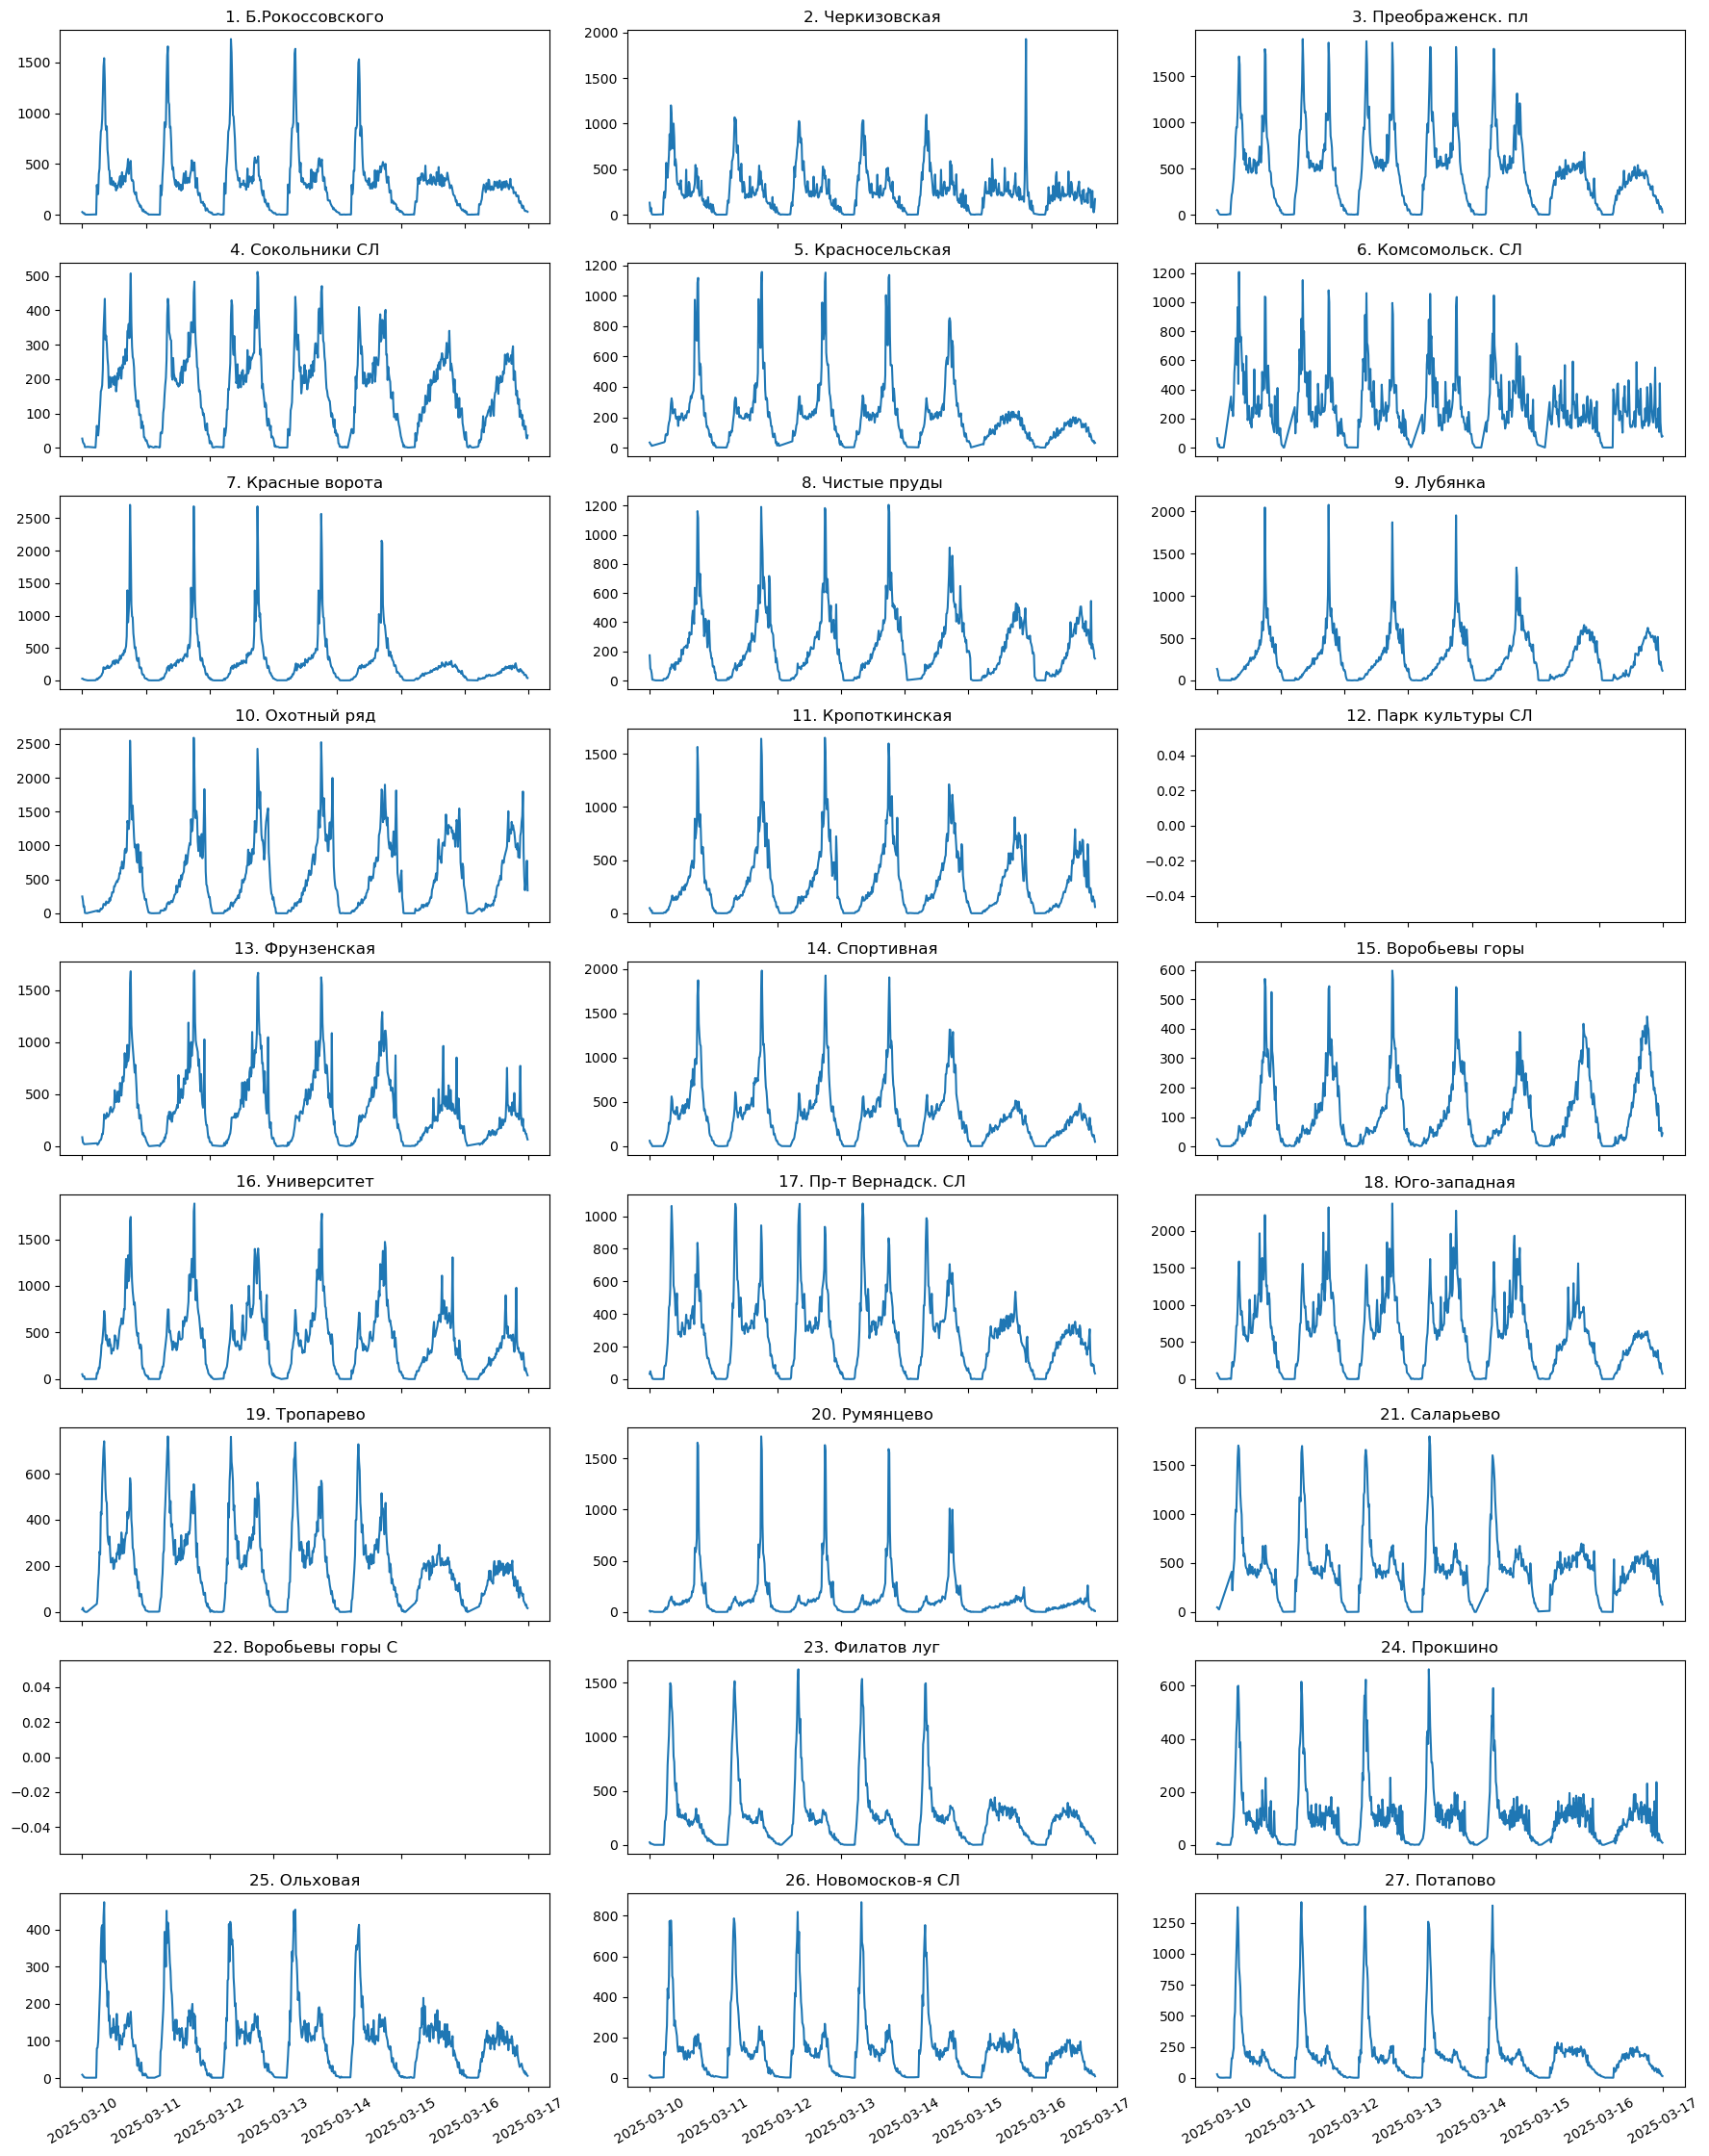

In [12]:
LINE_TO_PLOT = 'Сокольническая'

line_stations = result['stations'][
    result['stations']['LN_NAME_SHORT'].astype(str).str.contains(
        LINE_TO_PLOT,
        case=False,
        na=False,
    )
].sort_values([
    'station_order_on_line_proxy',
    'ST_CODE',
    'station_key',
])

line_flow = result['buckets'][
    result['buckets']['station_key'].isin(line_stations['station_key'])
].merge(
    line_stations[['station_key', 'ST_NAME_SHORT']],
    on='station_key',
    how='left',
).sort_values([
    'station_key',
    cfg.time_col,
])

n = len(line_stations)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, max(4, 2.5 * nrows)),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, (_, station) in zip(axes, line_stations.iterrows()):
    g = line_flow[line_flow['station_key'] == station['station_key']].sort_values(cfg.time_col)
    ax.plot(g[cfg.time_col], g['count'])
    ax.set_title(
        f"{int(station['station_order_on_line_proxy'])}. "
        f"{station['ST_NAME_SHORT']}"
    )
    ax.tick_params(axis='x', rotation=30)

for ax in axes[n:]:
    ax.axis('off')

fig.tight_layout()
plt.show()

## График прогноза

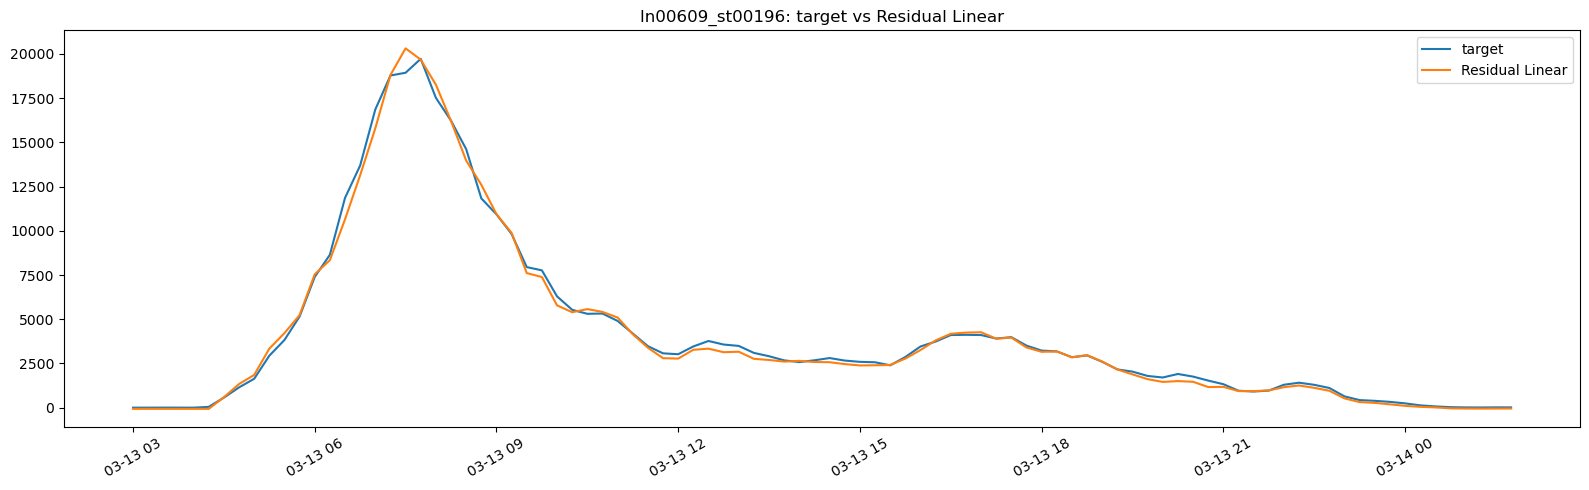

In [14]:
best_model = result['micro_table']['LW-MAE'].idxmin()

sample_station = (
    result['test_pred_table']
    .groupby('station_key')['y_true']
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

plot_df = (
    result['test_pred_table'][
        result['test_pred_table']['station_key'] == sample_station
    ]
    .sort_values(cfg.time_col)
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(plot_df[cfg.time_col], plot_df['y_true'], label='target')
ax.plot(plot_df[cfg.time_col], plot_df[best_model], label=best_model)
ax.set_title(f"{sample_station}: target vs {best_model}")
ax.legend()
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()